# Notebook Purpose

**Pairs Trading Mean Reversion** notebook for **highly correlated assets** (>0.7 corr).

Loads 2 CSV prices → Linear regression → Spread analysis → Z-score trading signals (buy/sell/neutral).

In [58]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [59]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ASSET1_FILE = "../../data/test_mean_reversion/JPM_1d_2009-04-01_2026-03-01.csv"
ASSET2_FILE = "../../data/test_mean_reversion/BAC_1d_2009-04-01_2026-03-01.csv"

# Extract tickers from filenames
asset1_ticker = ASSET1_FILE.split('/')[-1].split('_')[0]
asset2_ticker = ASSET2_FILE.split('/')[-1].split('_')[0]

df1 = pd.read_csv(ASSET1_FILE, parse_dates=['Date']).set_index('Date')['Adj Close'].rename(asset1_ticker)
df2 = pd.read_csv(ASSET2_FILE, parse_dates=['Date']).set_index('Date')['Adj Close'].rename(asset2_ticker)

df = pd.DataFrame({asset1_ticker: df1, asset2_ticker: df2}).dropna()
print(f"Common period: {len(df)} days")
print(df.head())

Common period: 4254 days
                  JPM       BAC
Date                           
2009-04-01  18.560995  5.425773
2009-04-02  18.607254  5.571996
2009-04-03  19.347315  5.849060
2009-04-06  18.633680  5.756707
2009-04-07  18.005949  5.664352


In [60]:
asset1_col = list(df.columns)[0]
asset2_col = list(df.columns)[1]

# Prepare data (asset2 predicts asset1)
X = df[[asset2_col]].values
y = df[asset1_col].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Results
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

print(f"Regression: {asset1_col} = {intercept:.2f} + {slope:.4f} * {asset2_col}")
print(f"R² = {r2:.4f}")
print(f"Slope = {slope:.4f}")

Regression: JPM = -27.64 + 5.4962 * BAC
R² = 0.9003
Slope = 5.4962


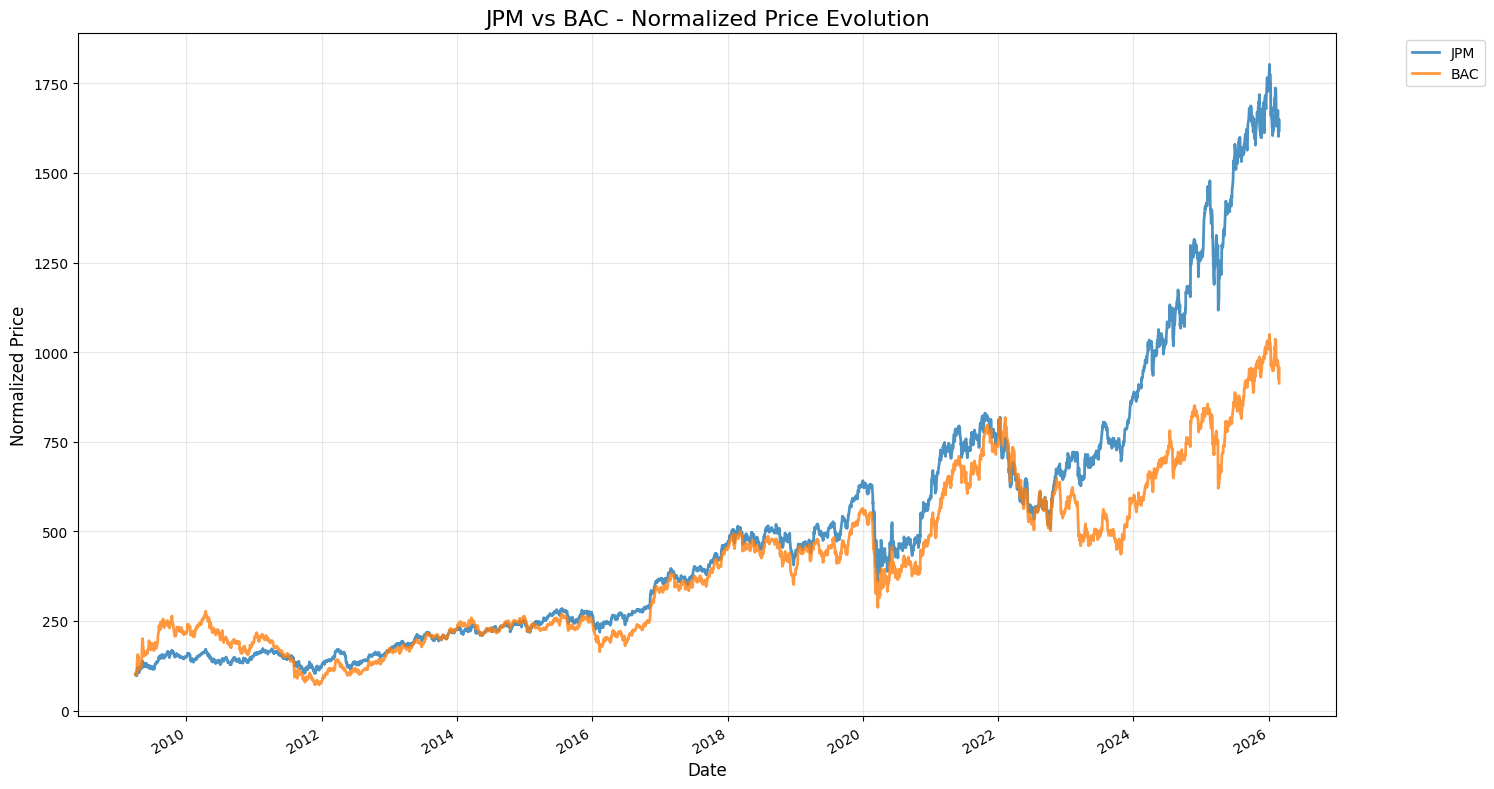

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Normalize to 100 (just the two price curves)
normalized_prices = (df / df.iloc[0]) * 100
normalized_prices.plot(ax=ax, linewidth=2, alpha=0.8)

ax.set_title(f'{asset1_col} vs {asset2_col} - Normalized Price Evolution', fontsize=16)
ax.set_ylabel('Normalized Price', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

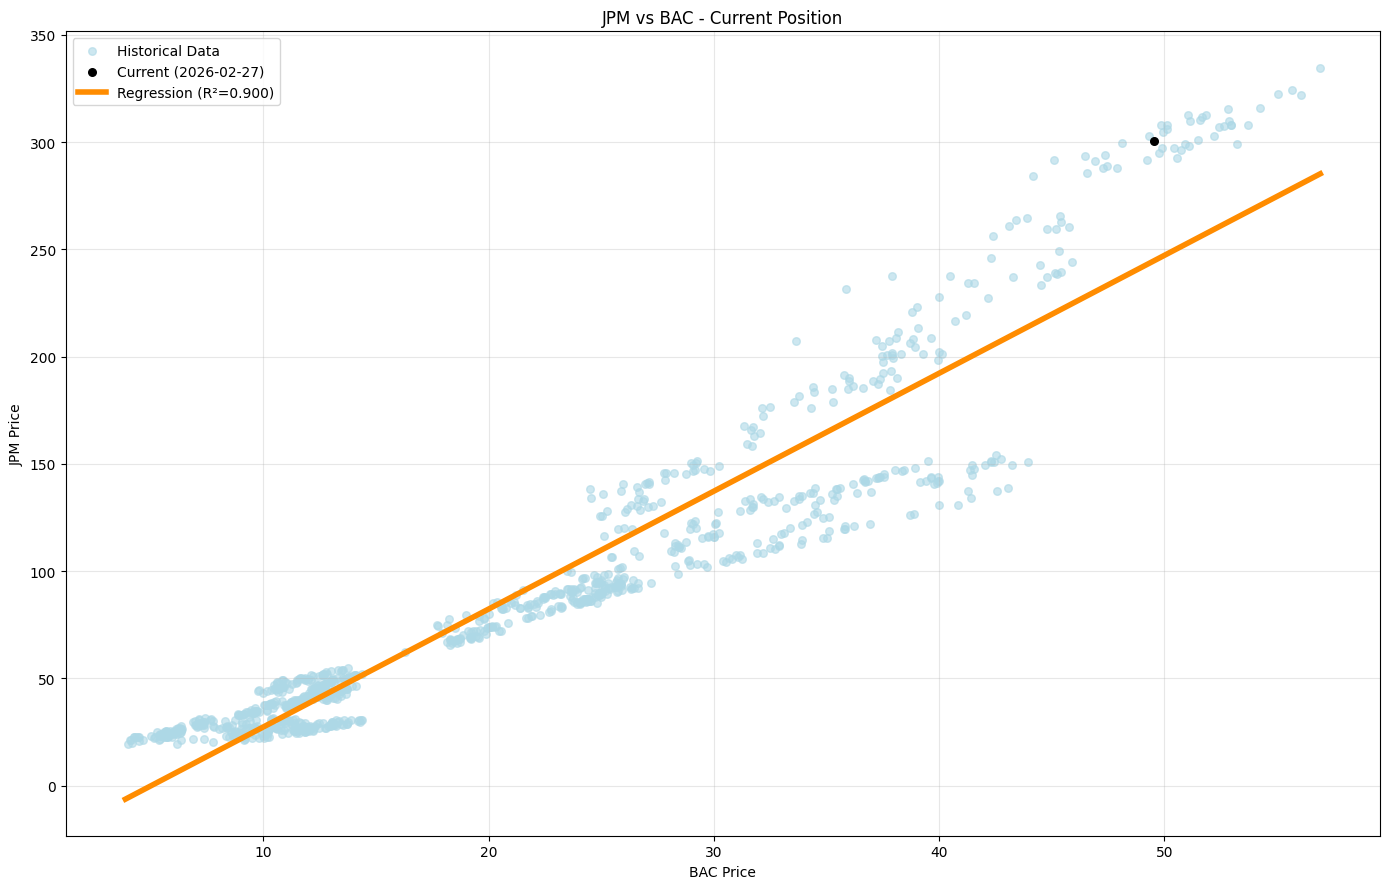

In [62]:
plt.figure(figsize=(14, 9))

# Sample historical data (max 1000 points)
sample_size = min(1000, len(df)-1)
df_sample = df.sample(n=sample_size, random_state=42)

# Historical points (light blue)
plt.scatter(df_sample[asset2_col], df_sample[asset1_col], alpha=0.6, s=30, label='Historical Data', color='lightblue')

# Current point (black, same size)
current_point = df.iloc[-1]
plt.scatter(current_point[asset2_col], current_point[asset1_col],  color='black', s=30, label=f'Current ({current_point.name.strftime("%Y-%m-%d")})', zorder=5)

# Regression line
x_range = np.linspace(df[asset2_col].min(), df[asset2_col].max(), 100)
y_pred = model.predict(x_range.reshape(-1, 1))
plt.plot(x_range, y_pred, color='darkorange', linewidth=4, label=f'Regression (R²={r2:.3f})')

plt.xlabel(f'{asset2_col} Price')
plt.ylabel(f'{asset1_col} Price')
plt.title(f'{asset1_col} vs {asset2_col} - Current Position')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distance from regression line
current_pred = model.predict([[current_point[asset2_col]]])[0]
distance = abs(current_point[asset1_col] - current_pred)

/home/charly/Documents/Projets/quant-personal-tests/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


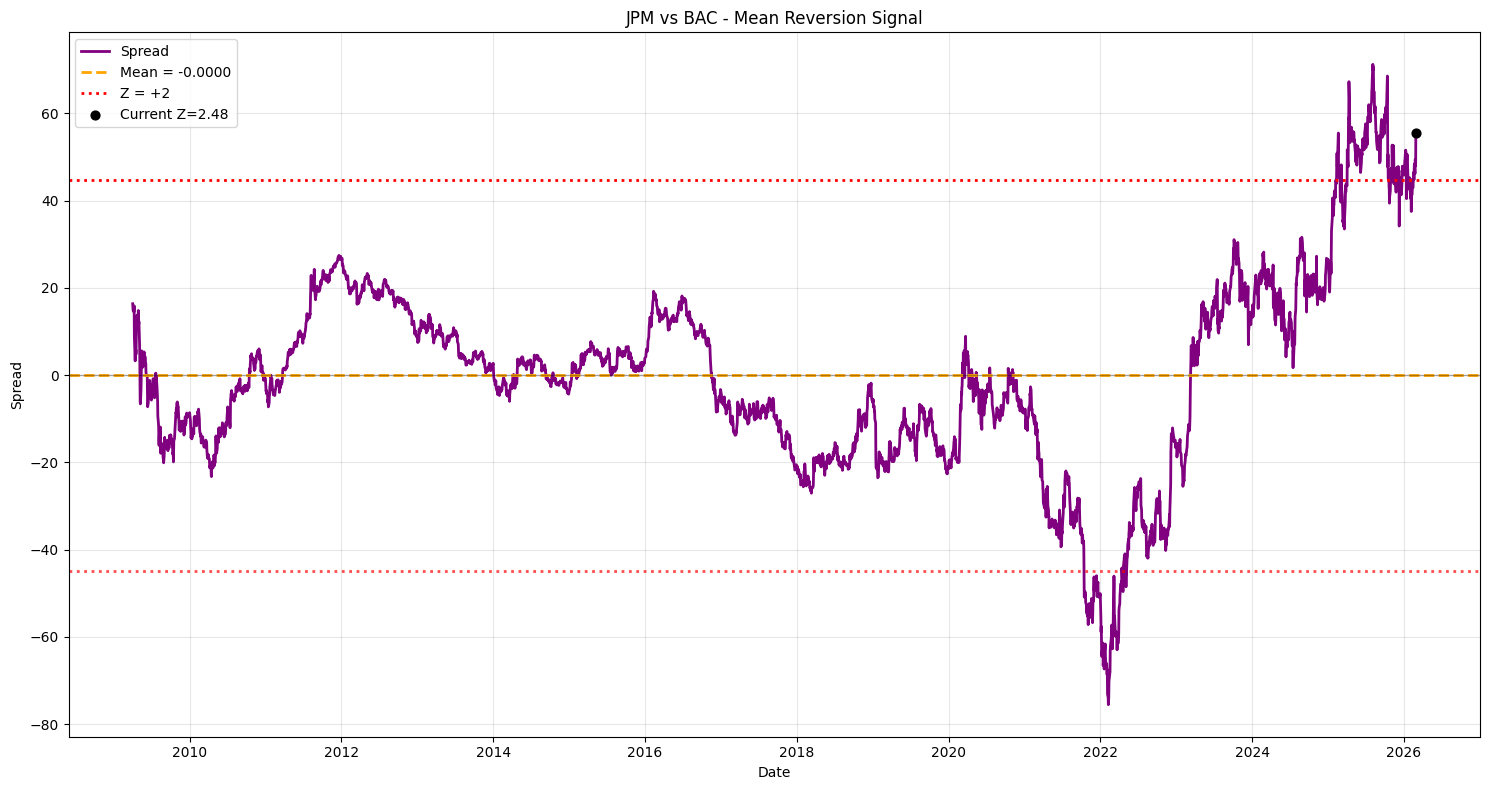

📊 SPREAD STATISTICS
----------------------------------------
Mean:      -0.0000
Max:       71.2560
Min:       -75.5206
Std Dev:   22.3807
Current:   55.6083
Z-Score:   2.48


In [63]:
# Calculate spread locally
spread = df[asset1_col] - model.predict(df[[asset2_col]])
mean_spread = spread.mean()
std_spread = spread.std()
z_score = (spread.iloc[-1] - mean_spread) / std_spread

fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Plot spread only
ax.plot(df.index, spread, linewidth=2, color='purple', label='Spread')
ax.axhline(y=mean_spread, color='orange', linewidth=2, linestyle='--', label=f'Mean = {mean_spread:.4f}')
ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.3)

# Z-Score threshold lines
ax.axhline(y=mean_spread + 2*std_spread, color='red', linewidth=2, linestyle=':', label='Z = +2')
ax.axhline(y=mean_spread - 2*std_spread, color='red', linewidth=2, linestyle=':', alpha=0.7)

# Current point
ax.scatter(df.index[-1], spread.iloc[-1], color='black', s=40, zorder=5, label=f'Current Z={z_score:.2f}')

ax.set_title(f'{asset1_col} vs {asset2_col} - Mean Reversion Signal')
ax.set_xlabel('Date')
ax.set_ylabel('Spread')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Spread Statistics Table
print("📊 SPREAD STATISTICS")
print("-" * 40)
print(f"Mean:      {mean_spread:.4f}")
print(f"Max:       {spread.max():.4f}")
print(f"Min:       {spread.min():.4f}")
print(f"Std Dev:   {std_spread:.4f}")
print(f"Current:   {spread.iloc[-1]:.4f}")
print(f"Z-Score:   {z_score:.2f}")

In [64]:
z_score = (spread.iloc[-1] - mean_spread) / std_spread

print("🎯 MEAN REVERSION STRATEGY SIGNALS")
print("=" * 60)
print(f"Pair: {asset1_col} vs {asset2_col}")
print(f"Current Z-Score: {z_score:.2f}")
print()

if z_score > 1.8:
    print("🔴 SELL SIGNAL")
    print(f"  → {asset1_col} is {z_score:.1f}σ ABOVE mean → OVERVALUED")
    print(f"  → SHORT {asset1_col} / LONG {asset2_col}")
    print("  → Target: Z-Score = 0 (mean reversion)")
    
elif z_score < -1.8:
    print("🟢 BUY SIGNAL") 
    print(f"  → {asset1_col} is {z_score:.1f}σ BELOW mean → UNDERVALUED")
    print(f"  → LONG {asset1_col} / SHORT {asset2_col}")
    print("  → Target: Z-Score = 0 (mean reversion)")
    
else:
    print("🟡 NEUTRAL")
    print(f"  → Z-Score {z_score:.1f} within normal range [-1.8, +1.8]")
    print("  → No trade signal - wait for extreme deviation")

print(f"\n📊 Stats Summary:")
print(f"   R²: {r2:.3f} (regression quality)")
print(f"   Mean spread: {mean_spread:.4f}")
print(f"   Current spread: {spread.iloc[-1]:.4f}")
print(f"   Distance to mean: {abs(spread.iloc[-1] - mean_spread):.4f}")

🎯 MEAN REVERSION STRATEGY SIGNALS
Pair: JPM vs BAC
Current Z-Score: 2.48

🔴 SELL SIGNAL
  → JPM is 2.5σ ABOVE mean → OVERVALUED
  → SHORT JPM / LONG BAC
  → Target: Z-Score = 0 (mean reversion)

📊 Stats Summary:
   R²: 0.900 (regression quality)
   Mean spread: -0.0000
   Current spread: 55.6083
   Distance to mean: 55.6083


---

## Mean reversion - Dynamic allocation - Z-score positive & negative

🎯 Dynamic allocation 50%/100% strategy


/home/charly/Documents/Projets/quant-personal-tests/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


💰 Initial Capital:     1000.00€
🎯 Dynamic 50-100%:     8538.72€ (+753.9%) | Sharpe: 0.54
💰 Buy & Hold 50/50:    12655.70€ (+1165.6%) | Sharpe: 0.63
🏆 Sharpe Winner:       BUY & HOLD
💸 Total Fees Paid:     6.5% (13 reallocs)
⚙️  Switch@|Z|>1.0, Neutral@|Z|<=0.1
🔴 100% trades: 7 | 🟢 50/50 trades: 6

📋 REALLOCATION LOG (first 8):
  REALLOC 2010-04-14 → 100% JPM (Z=-1.03)
  REALLOC 2011-08-08 → 100% BAC (Z=1.02)
  REALLOC 2018-01-05 → 100% JPM (Z=-1.01)
  REALLOC 2019-01-25 → 100% JPM (Z=-1.05)
  REALLOC 2021-03-18 → 100% JPM (Z=-1.03)
  REALLOC 2023-09-22 → 100% BAC (Z=1.01)
  REALLOC 2024-08-05 → 100% BAC (Z=1.03)
  REALLOC 2010-08-24 → 50/50 (Z=-0.09)


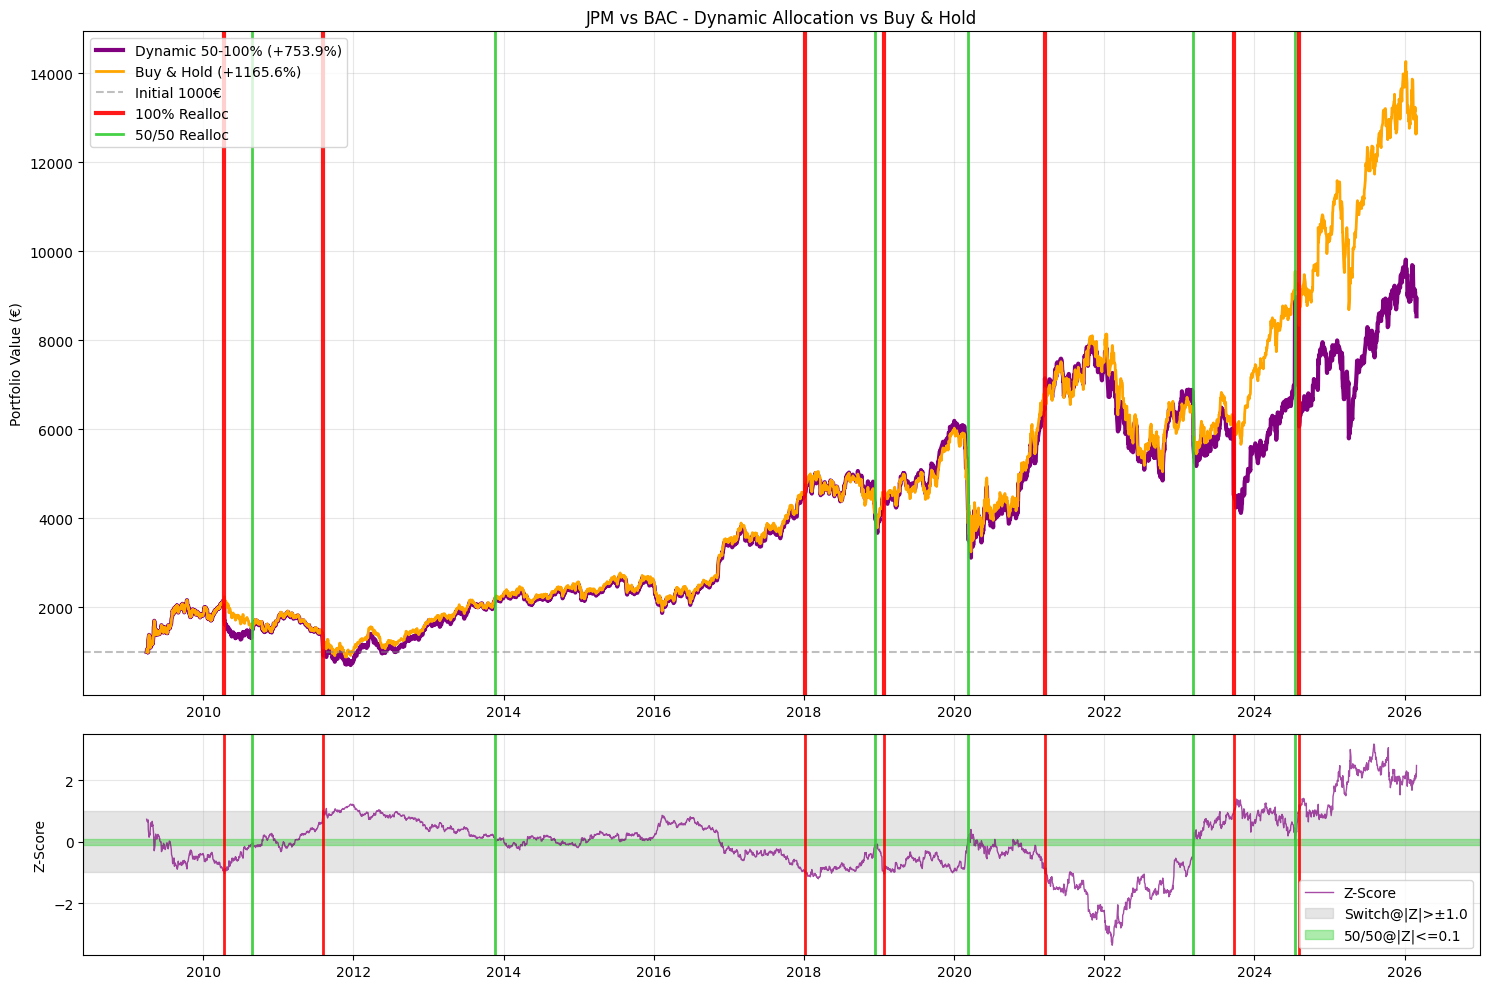

In [68]:
print("🎯 Dynamic allocation 50%/100% strategy")
print("=" * 70)

# Calculate Z-Score history
spread = df[asset1_col] - model.predict(df[[asset2_col]])
z_scores = (spread - spread.mean()) / spread.std()

# Parameters
initial_capital = 1000.0
switch_threshold = 1.0
neutral_threshold = 0.1
fees_pct = 0.005
total_fees = 0.0

n_days = len(df)
equity_curve = [initial_capital] * n_days
buy_hold_curve = [initial_capital] * n_days
trades_100 = []
trades_50 = []

price1_start = df[asset1_col].iloc[0]
price2_start = df[asset2_col].iloc[0]
shares_asset1_bh = 500 / price1_start
shares_asset2_bh = 500 / price2_start

allocation_asset1 = 0.5

for i in range(n_days):
    z = z_scores.iloc[i]
    date = df.index[i]
    price1_current = df[asset1_col].iloc[i]
    price2_current = df[asset2_col].iloc[i]
    
    bh_value = shares_asset1_bh * price1_current + shares_asset2_bh * price2_current
    buy_hold_curve[i] = bh_value
    
    prev_allocation = allocation_asset1
    
    # Logique mean reversion
    if z > switch_threshold:
        allocation_asset1 = 0.0
    elif z < -switch_threshold:
        allocation_asset1 = 1.0
    elif abs(z) <= neutral_threshold:
        allocation_asset1 = 0.5
    
    allocation_asset2 = 1.0 - allocation_asset1
    
    # Classification + fees
    if abs(allocation_asset1 - prev_allocation) >= 0.25:
        total_fees += fees_pct
        target = "50/50" if allocation_asset1 == 0.5 else f"100% {asset1_col if allocation_asset1==1.0 else asset2_col}"
        
        if allocation_asset1 == 0.5:
            trades_50.append((date, target, z))
        else:
            trades_100.append((date, target, z))
    
    performance_asset1 = price1_current / price1_start
    performance_asset2 = price2_current / price2_start
    equity_curve[i] = initial_capital * (1 - total_fees) * (allocation_asset1 * performance_asset1 + allocation_asset2 * performance_asset2)

# Sharpe + résultats
def sharpe_ratio(returns):
    if len(returns) < 2 or np.std(returns) == 0:
        return 0
    return np.mean(returns) / np.std(returns) * np.sqrt(252)

daily_returns_dyn = np.diff(equity_curve) / np.array(equity_curve[:-1])
daily_returns_bh = np.diff(buy_hold_curve) / np.array(buy_hold_curve[:-1])
dyn_sharpe = sharpe_ratio(daily_returns_dyn)
bh_sharpe = sharpe_ratio(daily_returns_bh)

dyn_return = (equity_curve[-1] - initial_capital) / initial_capital * 100
bh_return = (buy_hold_curve[-1] - initial_capital) / initial_capital * 100

print(f"💰 Initial Capital:     1000.00€")
print(f"🎯 Dynamic 50-100%:     {equity_curve[-1]:.2f}€ ({dyn_return:+.1f}%) | Sharpe: {dyn_sharpe:.2f}")
print(f"💰 Buy & Hold 50/50:    {buy_hold_curve[-1]:.2f}€ ({bh_return:+.1f}%) | Sharpe: {bh_sharpe:.2f}")
print(f"🏆 Sharpe Winner:       {'DYNAMIC' if dyn_sharpe > bh_sharpe else 'BUY & HOLD'}")
print(f"💸 Total Fees Paid:     {total_fees*100:.1f}% ({len(trades_100)+len(trades_50)} reallocs)")
print(f"⚙️  Switch@|Z|>{switch_threshold}, Neutral@|Z|<={neutral_threshold}")
print(f"🔴 100% trades: {len(trades_100)} | 🟢 50/50 trades: {len(trades_50)}")  # ✅ MAINTENANT >0 !

print("\n📋 REALLOCATION LOG (first 8):")
all_trades = trades_100 + trades_50
for date, target, z in all_trades[:8]:
    print(f"  REALLOC {date.strftime('%Y-%m-%d')} → {target} (Z={z:.2f})")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), height_ratios=[3, 1])

ax1.plot(df.index, equity_curve, linewidth=3, label=f'Dynamic 50-100% ({dyn_return:+.1f}%)', color='purple')
ax1.plot(df.index, buy_hold_curve, linewidth=2, label=f'Buy & Hold ({bh_return:+.1f}%)', color='orange')
ax1.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5, label='Initial 1000€')

for date, target, z in trades_100:
    ax1.axvline(x=date, color='red', linestyle='-', alpha=0.9, linewidth=3, label='100% Realloc' if (date, target, z) == trades_100[0] else "")
for date, target, z in trades_50:
    ax1.axvline(x=date, color='limegreen', linestyle='-', alpha=0.9, linewidth=2, label='50/50 Realloc' if (date, target, z) == trades_50[0] else "")

ax1.set_title(f'{asset1_col} vs {asset2_col} - Dynamic Allocation vs Buy & Hold')
ax1.set_ylabel('Portfolio Value (€)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, z_scores, color='purple', alpha=0.7, linewidth=1, label='Z-Score')
ax2.axhspan(-switch_threshold, switch_threshold, alpha=0.2, color='gray', label=f'Switch@|Z|>±{switch_threshold}')
ax2.axhspan(-neutral_threshold, neutral_threshold, alpha=0.4, color='limegreen', label=f'50/50@|Z|<={neutral_threshold}')

for date, target, z in trades_100:
    ax2.axvline(x=date, color='red', linestyle='-', alpha=0.9, linewidth=2)
for date, target, z in trades_50:
    ax2.axvline(x=date, color='limegreen', linestyle='-', alpha=0.9, linewidth=2)

ax2.set_ylabel('Z-Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()